In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
def calculate_monthly_averages(input_filepath, output_filepath):

    df = pd.read_csv(input_filepath)
    
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])
    
    date_col = 'Date'
    
    df[date_col] = pd.to_datetime(df[date_col].astype(str), format='%Y-%m-%d', errors='coerce')
    
    df = df.dropna(subset=[date_col])
    
    df['Date (YYYY-MM)'] = df[date_col].dt.to_period('M')
    
    monthly_avg = df.groupby('Date (YYYY-MM)').mean(numeric_only=True).reset_index()
    
    monthly_avg['Date (YYYY-MM)'] = monthly_avg['Date (YYYY-MM)'].astype(str)
    
    monthly_avg.sort_values(by='Date (YYYY-MM)', inplace=True)
    
    monthly_avg.to_csv(output_filepath, index=False)
    
if __name__ == "__main__":
    
    INPUT_CSV = '/Users/andydascikid/Python Scripts/Home/Yamuna Water Analysis/CSV Files/Final Dataset.csv'  
    OUTPUT_CSV = 'Monthly_Averaged_Final_Dataset.csv'
    
    calculate_monthly_averages(INPUT_CSV, OUTPUT_CSV)

In [3]:
df = pd.read_csv('Monthly_Averaged_Final_Dataset.csv')
df = df[df["Date (YYYY-MM)"].between('2021-01', '2025-03')]

In [4]:
df_cholera = pd.read_csv('/Users/andydascikid/Python Scripts/Home/Yamuna Water Analysis/CSV Files/Cholera Data.csv')

In [5]:
df['Cholera'] = df_cholera['Cholera']

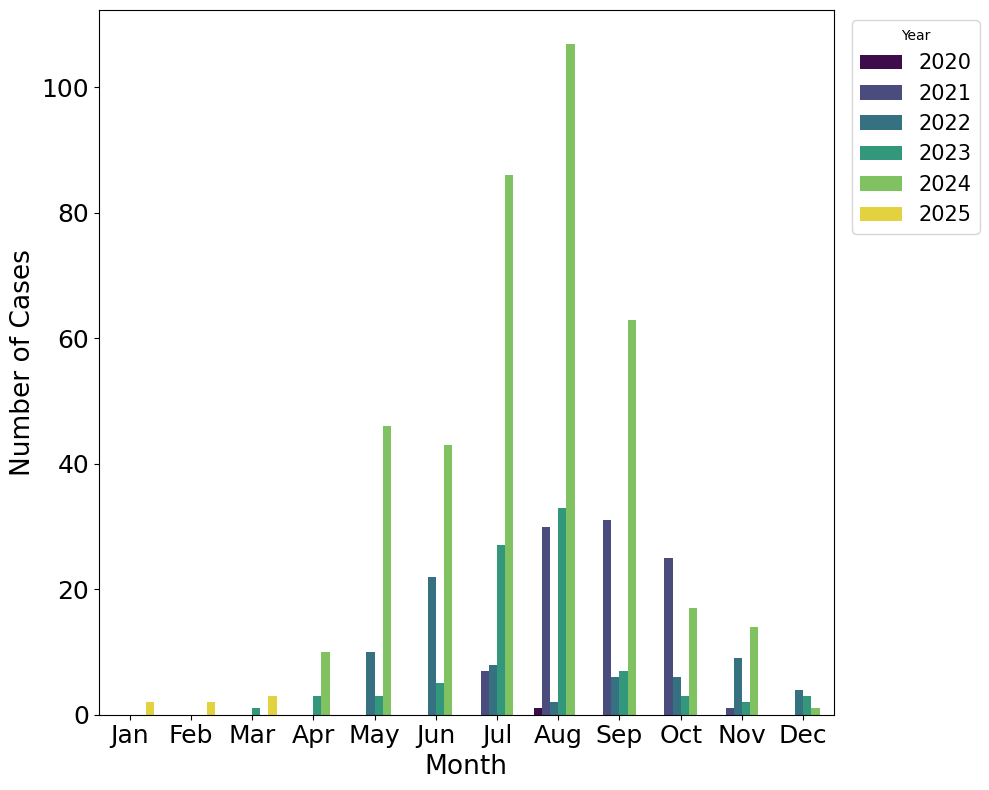

In [6]:
def plot_cholera_cases(csv_filepath):
    
    df = pd.read_csv(csv_filepath)
    
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')
    
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.strftime('%b') 
    
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
    
    plt.figure(figsize=(10, 8))
    
    sns.barplot(
        data=df, 
        x='Month', 
        y='Cholera', 
        hue='Year', 
        palette='viridis' 
    )
    
    plt.xlabel('Month', fontsize=19)
    plt.ylabel('Number of Cases', fontsize=19)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    
    plt.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize = 15)
    
    plt.tight_layout()
    plt.savefig('Cholera Cases.pdf')
    plt.show()

if __name__ == "__main__":
    plot_cholera_cases('/Users/andydascikid/Python Scripts/Home/Yamuna Water Analysis/CSV Files/Cholera Data.csv')

In [59]:
df.to_csv('Health & Environmental DataSet.csv')

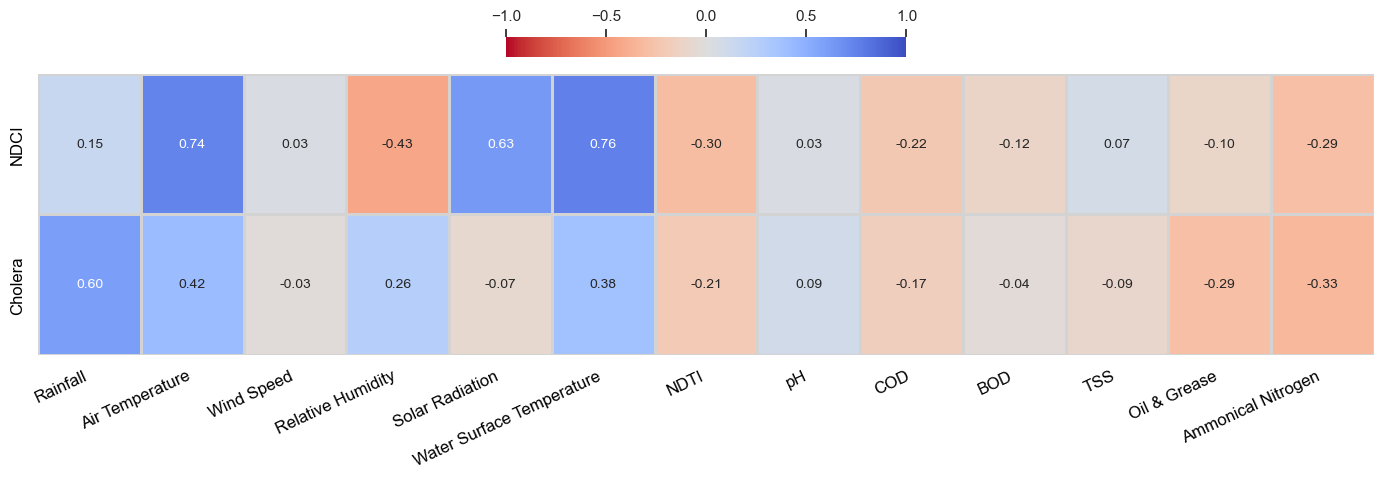

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_target_correlations(csv_filepath, target_a, target_b):

    df = pd.read_csv(csv_filepath)

    df = df.drop(columns=['Unnamed: 0'])

    df= df.rename(columns={
        'Rainfall [mm]' : 'Rainfall',
        'Air Temperature [C]' : 'Air Temperature',
        'Relative Humidity (%)' : 'Relative Humidity',
        'Ammonical Nitrogen (mg/L)' : 'Ammonical Nitrogen',
        'Water Surface Temperature [C]' : 'Water Surface Temperature',
        'Solar Radiation [J/m^2]' : 'Solar Radiation',
        'BOD (mg/L)' : 'BOD',
        'COD (mg/L)' : 'COD',
        'Oil & Grease (mg/L)' : 'Oil & Grease',
        'Wind Speed [m/s]' : 'Wind Speed'
    })
    
    numeric_df = df.select_dtypes(include=['float64', 'int64'])
    corr_matrix = numeric_df.corr()
    
    other_params = [col for col in corr_matrix.columns if col not in [target_a, target_b]]
    subset_corr = corr_matrix.loc[[target_a, target_b], other_params]
    
    ffig, ax = plt.subplots(figsize=(14, 5), facecolor='white')
    ax.set_facecolor('white')

    sns.heatmap(
        subset_corr,
        annot=True,             
        fmt=".2f",              
        annot_kws={"size": 10}, 
        cmap='coolwarm_r', 
        vmin=-1.0, vmax=1.0,
        linewidths=1, 
        linecolor='#d3d3d3', 
        ax=ax,
        cbar_kws={
            "orientation": "horizontal", 
            "location": "top", 
            "shrink": 0.3, 
            "pad": 0.05,
            "ticks": [-1.0, -0.5, 0.0, 0.5, 1.0]
        }
    )
    
    ax.tick_params(colors='black', labelsize=10)
    plt.xticks(rotation=25, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.tight_layout()
    plt.savefig('Correlation HeatMap.pdf')
    plt.show()


if __name__ == "__main__":
    plot_target_correlations('/Users/andydascikid/Python Scripts/Home/Yamuna Water Analysis/CSV Files/Health & Environmental DataSet.csv', 'NDCI', 'Cholera')
